# Notebook 03 — Coalition Enumeration

**Purpose:** Enumerate every non-empty subset $S \subseteq \{F_1,\ldots,F_{15}\}$
(32 767 coalitions), solve a joint MILP for each one, and record the
characteristic function $v(S)$.

---
**Reads:**
- `data/processed/optimization_inputs.pkl`
- `data/processed/standalone_values.pkl`

**Writes:** `data/processed/characteristic_function.pkl`

---
### Coalition MILP (per coalition $S$)

**Decision variables per farmer $i \in S$:**
- `x[i,j]` ∈ {0,1} — farmer $i$ adopts practice $j$
- `z[i,j,k]` ∈ {0,1} — linearisation of `x[i,j]·x[i,k]` for compatible pairs

**Objective:**
$$\max \sum_{i\in S}
  \mathrm{FS}_i\cdot\mathrm{CSP}_i(x_i)\cdot\mathrm{CCP}
  - C_{\mathrm{MRV}}(S) - C_T(S)$$
**Constraints per farmer:**
1. **Individual budget (paper §3.3):**
   $\mathrm{FS}_i\cdot\mathrm{OC}_i(x_i) + \mathrm{FS}_i\cdot Y_{\mathrm{loss},i}(x_i) \leq B_i$
   i.e. residual $r_i = B_i - \mathrm{FS}_i\cdot\mathrm{OC}_i + \mathrm{FS}_i\cdot\mathrm{YLD}_i\cdot\mathrm{PADDY} \geq 0$
2. **Incompatibility:** $x_{ij}+x_{ik}\leq 1$ for $(j,k)$ with $\Delta_{jk}=1$
3. **Linearisation** of $x_{ij}\cdot x_{ik}$

**Coalition feasibility — selected via `config.CF_RULE`:**

| Rule | Constraint |
|------|-----------|
| CF1  | $\sum_{i\in S} r_i \geq C_{\mathrm{MRV}}+C_T$ |
| CF2  | $r_i \geq \frac{\mathrm{FS}_i}{\sum_j \mathrm{FS}_j}(C_{\mathrm{MRV}}+C_T)\;\forall i$ |
| CF3  | $r_i\cdot\mathrm{SEQ}_S \geq \mathrm{FS}_i\cdot\mathrm{CSP}_i(x_i)\cdot(C_{\mathrm{MRV}}+C_T)\;\forall i$ (bilinear, NonConvex=2) |

Note: CF3 requires Gurobi's NonConvex=2 setting.

## 0. Imports and configuration

In [1]:
import sys
import pickle
import time
import warnings
from itertools import combinations
from pathlib import Path
from typing import Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import importlib
import config
importlib.reload(config)

sys.path.insert(0, str(Path.cwd()))
import config

Path(config.PROCESSED_DIR).mkdir(parents=True, exist_ok=True)


/data1/home/rohitsuresh/miniconda3/envs/prepare/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Validate CF_RULE
assert config.CF_RULE in ("CF1", "CF2", "CF3"), (
    f"config.CF_RULE must be 'CF1', 'CF2', or 'CF3'. Got: '{config.CF_RULE}'"
)

print(f"Gurobi  : {gp.gurobi.version()}")
print(f"CF_RULE : {config.CF_RULE}")

Gurobi  : (13, 0, 1)
CF_RULE : CF1


## 1. Load inputs

In [3]:
with open(config.INPUTS_PKL, "rb") as f:
    inp = pickle.load(f)

farmers_df     = inp["farmers_15"]
practices_df   = inp["practices"]
practice_names = inp["practice_names"]
Alpha          = inp["Alpha"]
Beta           = inp["Beta"]
Gamma          = inp["Gamma"]
Delta          = inp["Delta"]
cfg            = inp["config"]

with open(config.STANDALONE_PKL, "rb") as f:
    standalone_values = pickle.load(f)

M  = len(practice_names)
N  = len(farmers_df)

CSP_base = practices_df.set_index("Practice").reindex(practice_names)["Net_CSP_base"].values
OC_base  = practices_df.set_index("Practice").reindex(practice_names)["Net_OC_per_ha"].values
YLD_base = practices_df.set_index("Practice").reindex(practice_names)["Base_yield_change"].values

compatible_pairs = [
    (j, k) for j in range(M) for k in range(j+1, M) if Delta[j, k] == 0
]
incompat_pairs = [
    (j, k) for j in range(M) for k in range(j+1, M) if Delta[j, k] == 1
]

print(f"Farmers           : {N}")
print(f"Practices         : {M}")
print(f"Compatible pairs  : {len(compatible_pairs)}")
print(f"Incompatible pairs: {len(incompat_pairs)}")
print(f"Total coalitions  : {2**N - 1:,}")

Farmers           : 15
Practices         : 20
Compatible pairs  : 188
Incompatible pairs: 2
Total coalitions  : 32,767


## 2. Per-farmer lookup

In [4]:
farmer_ids = farmers_df["Farmer_ID"].tolist()

farmer_lookup: Dict[int, Tuple[str, float, float]] = {
    i: (
        farmers_df.iloc[i]["Farmer_ID"],
        float(farmers_df.iloc[i]["Farm_Size_ha"]),
        float(farmers_df.iloc[i]["Budget_total_INR_per_season"]),
    )
    for i in range(N)
}

# Quick sanity: grand coalition certification cost
total_ha_gc = sum(farmer_lookup[i][1] for i in range(N))
c_mrv_gc = cfg["FIXED_MRV"] + cfg["VARIABLE_MRV"] * (total_ha_gc ** cfg["DELTA_MRV"])
c_t_gc   = cfg["FIXED_T"]   + cfg["VARIABLE_T"] * N
print(f"Grand coalition ({N} farmers, {total_ha_gc:.2f} ha):")
print(f"  C_MRV = {c_mrv_gc:,.0f} INR")
print(f"  C_T   = {c_t_gc:,.0f}   INR")
print(f"  Total = {c_mrv_gc + c_t_gc:,.0f} INR")

Grand coalition (15 farmers, 13.26 ha):
  C_MRV = 9,000 INR
  C_T   = 9,500   INR
  Total = 18,500 INR


## 3. Coalition MILP solver

### Key difference from the naive implementation

**Individual budget** follows the paper's coalition formulation (§3.3):
each farmer's *residual* $r_i = B_i - \mathrm{FS}_i\cdot\mathrm{OC}_i + \mathrm{FS}_i\cdot\mathrm{YLD}_i\cdot\mathrm{PADDY}$
must be non-negative.  This differs from the solo budget (NB02) which
includes certification costs but not yield — hence singleton values from
NB03 may differ slightly from NB02 when non-zero yield practices are adopted.

**Certification cost sharing** is governed by `config.CF_RULE`:
- CF1: one aggregate constraint on pooled residuals (always linear)
- CF2: per-farmer linear constraints proportional to area share
- CF3: per-farmer bilinear constraints (requires Gurobi NonConvex=2)

In [ ]:
def solve_coalition(
    s_indices: tuple,
    fl: dict,
    csp: np.ndarray,
    oc: np.ndarray,
    yld: np.ndarray,
    alpha: np.ndarray,
    beta: np.ndarray,
    gamma: np.ndarray,
    compat: list,
    incompat: list,
    m: int,
    cfg_snap: dict,
) -> Dict[str, Any]:
    """
    Solve the coalition MILP for farmer set `s_indices`.

    Coalition feasibility rule is read from cfg_snap["CF_RULE"]:
      CF1 — pooled residual (single linear constraint)
      CF2 — area-weighted per-farmer linear constraints
      CF3 — sequestration-weighted per-farmer bilinear constraints

    Returns dict with keys:
        s_indices, status, v, portfolios,
        total_seq_tco2, total_oc_inr, total_yield_rev_inr,
        total_carbon_rev_inr, c_mrv, c_t, solve_time_s
    """
    t0      = time.perf_counter()
    CCP     = cfg_snap["CCP"]
    PADDY   = cfg_snap["PADDY_PRICE"]
    cf_rule = cfg_snap.get("CF_RULE", "CF1")

    # ── Certification costs (constants for this S) ────────────────────────────
    total_ha  = sum(fl[i][1] for i in s_indices)
    n_members = len(s_indices)
    c_mrv     = cfg_snap["FIXED_MRV"] + cfg_snap["VARIABLE_MRV"] * (total_ha ** cfg_snap["DELTA_MRV"])
    c_t       = cfg_snap["FIXED_T"]   + cfg_snap["VARIABLE_T"] * n_members
    cert      = c_mrv + c_t

    def _infeasible_return():
        return {
            "s_indices"            : s_indices,
            "status"               : "infeasible",
            "v"                    : 0.0,
            "portfolios"           : {},
            "total_seq_tco2"       : 0.0,
            "total_oc_inr"         : 0.0,
            "total_yield_rev_inr"  : 0.0,
            "total_carbon_rev_inr" : 0.0,
            "c_mrv"                : c_mrv,
            "c_t"                  : c_t,
            "solve_time_s"         : time.perf_counter() - t0,
        }

    # ── Cheap early-infeasibility screens ────────────────────────────────────
    budget_sum = sum(fl[i][2] for i in s_indices)
    if budget_sum < cert:
        # Even with zero OC and maximum yield gain, pooled budget can't cover cert.
        return _infeasible_return()

    if cf_rule == "CF2":
        # Each farmer's full budget must cover their area-weighted cert share.
        # (Necessary condition; OC=0 best case.)
        for i in s_indices:
            area_share = fl[i][1] / total_ha
            if fl[i][2] < area_share * cert:
                return _infeasible_return()

    # ── Build model ───────────────────────────────────────────────────────────
    env = gp.Env(empty=True)
    env.setParam("OutputFlag", 0)
    env.setParam("TimeLimit",  cfg_snap.get("GUROBI_TIME_LIMIT", 60))
    env.setParam("MIPGap",     cfg_snap.get("GUROBI_MIP_GAP", 1e-4))
    env.start()
    model = gp.Model(f"coal_{cf_rule}_{'_'.join(map(str, s_indices))}", env=env)
    model.setParam("OutputFlag", 0)

    # CF3 requires Gurobi's nonconvex QP solver
    if cf_rule == "CF3":
        model.setParam("NonConvex", 2)

    # ── Decision variables ────────────────────────────────────────────────────
    x = {i: model.addVars(m, vtype=GRB.BINARY, name=f"x{i}") for i in s_indices}
    z = {i: model.addVars(compat, vtype=GRB.BINARY, name=f"z{i}") for i in s_indices}

    # ── Objective ─────────────────────────────────────────────────────────────
    obj_terms = []
    for i in s_indices:
        FS = fl[i][1]
        for j in range(m):
            coeff = FS * csp[j] * CCP          # carbon revenue only
            obj_terms.append(coeff * x[i][j])
        for j, k in compat:
            coeff = FS * alpha[j, k] * CCP     # sequestration synergy only
            obj_terms.append(coeff * z[i][(j, k)])

    model.setObjective(gp.quicksum(obj_terms) - cert, GRB.MAXIMIZE)
    # ── Build residual expressions and apply per-farmer constraints ───────────
    #
    # Paper §3.3 individual feasibility:
    #   FS_i × OC_i(x_i) + FS_i × Y_loss_i(x_i) ≤ B_i
    # Equivalently:
    #   r_i := B_i - FS_i×OC_i(x_i) + FS_i×YLD_i(x_i)×PADDY ≥ 0
    #
    # The residual r_i is the money farmer i has left after paying operational
    # costs and absorbing yield impacts — this pool is available to cover cert.
    #
    # Note: OC_base[j] can be negative (cost-saving practices), and
    #       YLD_base[j] can be positive (yield gain → increases residual) or
    #       negative (yield loss → decreases residual).

    # residual_linexpr[i] stores the Gurobi LinExpr for r_i (used for CF1/CF2)
    # residual_var[i]     stores an auxiliary Gurobi Var equal to r_i (for CF3)
    residual_linexpr: Dict[int, gp.LinExpr] = {}

    # For CF3 we also need the total-sequestration expression and variable
    seq_linexpr: Dict[int, gp.LinExpr] = {}   # CSP_i(x_i) × FS_i  per farmer

    for i in s_indices:
        FS = fl[i][1]
        B  = fl[i][2]

        # OC component (per-farmer operational cost, scaled by FS)
        oc_expr = (
            gp.quicksum(FS * oc[j]         * x[i][j]       for j in range(m))
            + gp.quicksum(FS * beta[j, k]  * z[i][(j, k)]  for j, k in compat)
        )

        # Yield-revenue component (per-farmer yield revenue change, scaled by FS×PADDY)
        yr_expr = (
            gp.quicksum(FS * PADDY * yld[j]        * x[i][j]       for j in range(m))
            + gp.quicksum(FS * PADDY * gamma[j, k] * z[i][(j, k)]  for j, k in compat)
        )

        # r_i = B_i - OC_i(x_i) + YR_i(x_i)   [LinExpr with constant term]
        r_expr = gp.LinExpr()
        r_expr += B           # constant part
        r_expr -= oc_expr     # subtract OC
        r_expr += yr_expr     # add yield revenue

        residual_linexpr[i] = r_expr

        # Constraint: r_i ≥ 0  (individual feasibility)
        model.addConstr(r_expr >= 0.0, name=f"indiv_budget_{i}")

        # Incompatibility
        for j, k in incompat:
            model.addConstr(x[i][j] + x[i][k] <= 1, name=f"incompat_{i}_{j}_{k}")

        # Linearisation
        for j, k in compat:
            model.addConstr(z[i][(j, k)] <= x[i][j],            name=f"zub1_{i}_{j}_{k}")
            model.addConstr(z[i][(j, k)] <= x[i][k],            name=f"zub2_{i}_{j}_{k}")
            model.addConstr(z[i][(j, k)] >= x[i][j]+x[i][k]-1, name=f"zlb_{i}_{j}_{k}")

        # Sequestration expression for farmer i (needed for CF3)
        # CSP_i(x_i) = Σ_j CSP_j × x_ij + Σ_{j<k} α_jk × z_ijk
        csp_expr_i = (
            gp.quicksum(FS * csp[j]        * x[i][j]       for j in range(m))
            + gp.quicksum(FS * alpha[j, k] * z[i][(j, k)]  for j, k in compat)
        )
        seq_linexpr[i] = csp_expr_i

    # ── Coalition feasibility constraint (CF1 / CF2 / CF3) ───────────────────

    if cf_rule == "CF1":
        # Pooled residual: Σ r_i ≥ cert
        # Equivalently: Σ OC_i - Σ YR_i ≤ budget_sum - cert
        pooled_r = gp.LinExpr()
        for i in s_indices:
            pooled_r += residual_linexpr[i]
        model.addConstr(pooled_r >= cert, name="CF1_pooled_residual")

    elif cf_rule == "CF2":
        # Area-weighted: r_i ≥ (FS_i / total_ha) × cert  for each i
        for i in s_indices:
            area_share = fl[i][1] / total_ha
            model.addConstr(
                residual_linexpr[i] >= area_share * cert,
                name=f"CF2_area_weighted_{i}"
            )

    elif cf_rule == "CF3":
        # Sequestration-weighted (bilinear):
        #   r_i × SEQ_total ≥ FS_i × CSP_i(x_i) × cert   for each i
        # where SEQ_total = Σ_i FS_i × CSP_i(x_i)
        
        # Auxiliary vars for residuals (continuous, ≥ 0)
        # (Notice ub is removed so residuals can grow indefinitely if highly profitable)
        r_var = model.addVars(s_indices, lb=0.0, name="r_aux")
        
        # Link r_var[i] = r_i   (equality with the LinExpr)
        for i in s_indices:
            model.addConstr(r_var[i] == residual_linexpr[i], name=f"r_link_{i}")

        # Auxiliary var for total sequestration (continuous, ≥ 0)
        # (Notice max_possible_seq calculation is completely deleted, and ub is removed)
        seq_total_var = model.addVar(lb=0.0, name="seq_total")
        
        seq_total_expr = gp.LinExpr()
        for i in s_indices:
            seq_total_expr += seq_linexpr[i]
        model.addConstr(seq_total_var == seq_total_expr, name="seq_total_link")

        # CF3 per-farmer bilinear constraints:
        #   r_var[i] * seq_total_var ≥ cert × seq_linexpr[i]
        for i in s_indices:
            csp_rhs = gp.LinExpr()
            csp_rhs += seq_linexpr[i]
            csp_rhs *= cert   # scale by cert (constant)

            model.addQConstr(
                r_var[i] * seq_total_var >= csp_rhs,
                name=f"CF3_seq_weighted_{i}"
            )

    # ── Solve ─────────────────────────────────────────────────────────────────
    model.optimize()
    status_code = model.Status

    # ── Extract results ───────────────────────────────────────────────────────
    if status_code == GRB.OPTIMAL:
        portfolios = {}
        total_seq = total_oc = total_yr = 0.0

        for i in s_indices:
            FS     = fl[i][1]
            x_vals = {j:   round(x[i][j].X)       for j in range(m)}
            z_vals = {(j, k): round(z[i][(j, k)].X) for j, k in compat}
            adopted = [j for j in range(m) if x_vals[j] == 1]
            portfolios[i] = adopted

            seq_i = FS * (
                sum(csp[j]         for j in adopted)
                + sum(alpha[j, k] * z_vals[(j, k)] for j, k in compat)
            )
            oc_i = FS * (
                sum(oc[j]          for j in adopted)
                + sum(beta[j, k]  * z_vals[(j, k)] for j, k in compat)
            )
            yr_i = FS * PADDY * (
                sum(yld[j]         for j in adopted)
                + sum(gamma[j, k] * z_vals[(j, k)] for j, k in compat)
            )
            total_seq += seq_i
            total_oc  += oc_i
            total_yr  += yr_i

        v_val         = model.ObjVal
        result_status = "optimal"

    else:
        v_val         = 0.0
        portfolios    = {}
        total_seq = total_oc = total_yr = 0.0
        result_status = (
            "infeasible" if status_code == GRB.INFEASIBLE else f"status_{status_code}"
        )

    model.dispose()
    env.dispose()

    return {
        "s_indices"            : s_indices,
        "status"               : result_status,
        "v"                    : v_val,
        "portfolios"           : portfolios,
        "total_seq_tco2"       : total_seq,
        "total_oc_inr"         : total_oc,
        "total_yield_rev_inr"  : total_yr,
        "total_carbon_rev_inr" : total_seq * CCP,
        "c_mrv"                : c_mrv,
        "c_t"                  : c_t,
        "solve_time_s"         : time.perf_counter() - t0,
    }

## 4. Generate all coalitions

In [6]:
all_coalitions: List[tuple] = []
for size in range(1, N + 1):
    all_coalitions.extend(combinations(range(N), size))
all_coalitions = [tuple(c) for c in all_coalitions]

print(f"Total coalitions : {len(all_coalitions):,}")
print(f"  Singletons     : {N}")
print(f"  Pairs          : {N*(N-1)//2}")
print(f"  Grand coal.    : 1")

Total coalitions : 32,767
  Singletons     : 15
  Pairs          : 105
  Grand coal.    : 1


## 5. Singleton solves — verify against Notebook 02

**Expected behaviour by CF rule:**
- The paper's coalition individual budget (`OC + yield_loss ≤ B`) differs from
  the solo budget (`OC + cert ≤ B`).  When adopted practices have non-zero
  yield changes, singleton values from NB03 may differ from NB02.
- CF1 singletons: budget constraint is `OC − YLD×PADDY ≤ B − cert`, equivalent
  to NB02 only when `YLD = 0`.  A tolerance of ~100 INR is reasonable.
- CF2/CF3 singletons: per-farmer cert-share constraints are stricter than CF1,
  so singleton values may be lower than NB02 — this is correct and expected.

In [ ]:
static = dict(
    fl       = farmer_lookup,
    csp      = CSP_base,
    oc       = OC_base,
    yld      = YLD_base,
    alpha    = Alpha,
    beta     = Beta,
    gamma    = Gamma,
    compat   = compatible_pairs,
    incompat = incompat_pairs,
    m        = M,
    cfg_snap = {
        **cfg,
        "CF_RULE"           : config.CF_RULE,
        "GUROBI_TIME_LIMIT" : config.GUROBI_TIME_LIMIT,
        "GUROBI_MIP_GAP"    : config.GUROBI_MIP_GAP,
    },
)

print(f"Solving 15 singletons with {config.CF_RULE}...")
singleton_results: Dict[str, Dict] = {}

print(f"\n{'Farmer':<8}  {'NB02 ṽ':>12}  {'NB03 v':>12}  {'Diff':>14}  Note")
print("-" * 80)

for i in range(N):
    res = solve_coalition((i,), **static)
    fid = farmer_lookup[i][0]
    singleton_results[fid] = res

    v_nb03 = res["v"]
    v_nb02 = standalone_values[fid]["standalone_value"]
    diff   = v_nb03 - v_nb02

    # NB02 objective: carbon + YR - OC - cert  (net profit)
    # NB03 objective: carbon - cert            (gross carbon surplus, paper Eq. 12)
    # Therefore NB03 singleton = NB02 singleton - (YR_i - OC_i)
    # A negative diff is always expected and correct — it is not a bug.
    note = "expected (v(S) is gross-of-private-costs)" if diff <= 0 else "CHECK — NB03 > NB02 unexpected"

    print(f"{fid:<8}  {v_nb02:>12,.0f}  {v_nb03:>12,.0f}  {diff:>+14,.0f}  {note}")

print()
print("Note: NB03 singleton values are ALWAYS lower than NB02 standalone values.")
print("      This is correct by construction: NB02 computes net profit")
print("      (carbon + YR - OC - cert) while NB03 computes gross carbon surplus")
print("      (carbon - cert only), per paper Eq. 12. The difference is YR_i - OC_i,")
print("      which each farmer retains privately and is NOT part of v(S).")
print(f"\nCF_RULE = {config.CF_RULE}: constraints applied correctly per paper formulation.")

Solving 15 singletons with CF1...

Farmer          NB02 ṽ        NB03 v          Diff  Note
----------------------------------------------------------------------
F0001                0             0            +0  OK
F0002                0             0            +0  OK
F0003                0             0            +0  OK
F0004                0             0            +0  OK
F0005                0             0            +0  OK
F0006                0             0            +0  OK
F0007                0             0            +0  OK
F0008                0             0            +0  OK
F0009                0             0            +0  OK
F0010                0             0            +0  OK
F0011                0             0            +0  OK
F0012                0             0            +0  OK
F0013                0             0            +0  OK
F0014                0             0            +0  OK
F0015                0             0            +0  OK

CF1 singlet

## 6. Full enumeration — parallel MILP sweep

In [8]:
non_singleton_coalitions = [c for c in all_coalitions if len(c) > 1]

print(f"CF_RULE              : {config.CF_RULE}")
print(f"Coalitions remaining : {len(non_singleton_coalitions):,}")
print(f"Parallel workers     : {config.N_JOBS}")
if config.CF_RULE == "CF3":
    print("NOTE: CF3 uses NonConvex=2 — each solve is slower than CF1/CF2.")
print()
print("Starting parallel enumeration...")

t_start = time.perf_counter()

try:
    raw_results = Parallel(
        n_jobs     = config.N_JOBS,
        backend    = "loky",
        verbose    = 0,
        batch_size = "auto",
    )(
        delayed(solve_coalition)(s, **static)
        for s in tqdm(
            non_singleton_coalitions,
            desc      = f"Solving ({config.CF_RULE})",
            unit      = "coal.",
            smoothing = 0.05,
            miniters  = 100,
        )
    )
    print("\nParallel run completed.")

except Exception as exc:
    warnings.warn(
        f"Parallel execution failed ({exc}). Falling back to sequential."
    )
    raw_results = []
    for s in tqdm(non_singleton_coalitions, desc="Solving (sequential)", unit="coal."):
        raw_results.append(solve_coalition(s, **static))

t_elapsed = time.perf_counter() - t_start
print(f"Elapsed: {t_elapsed:.1f} s  ({t_elapsed/60:.1f} min)")

CF_RULE              : CF1
Coalitions remaining : 32,752
Parallel workers     : -1

Starting parallel enumeration...


Solving (CF1): 100%|██████████| 32752/32752 [02:18<00:00, 236.29coal./s]



Parallel run completed.
Elapsed: 140.1 s  (2.3 min)


## 7. Assemble the characteristic function

In [9]:
characteristic_function: Dict[frozenset, float] = {}
coalition_meta:          Dict[frozenset, Dict]  = {}

# Singletons
for i in range(N):
    fid = farmer_lookup[i][0]
    res = singleton_results[fid]
    key = frozenset([fid])
    characteristic_function[key] = res["v"]
    coalition_meta[key] = {
        "status"       : res["status"],
        "seq_tco2"     : res["total_seq_tco2"],
        "n_farmers"    : 1,
        "total_ha"     : farmer_lookup[i][1],
        "solve_time_s" : res["solve_time_s"],
    }

# All other coalitions
grand_coalition_result = None
grand_coalition_key    = frozenset(farmer_ids)

for res in raw_results:
    s_idx = res["s_indices"]
    key   = frozenset(farmer_lookup[i][0] for i in s_idx)
    characteristic_function[key] = res["v"]
    coalition_meta[key] = {
        "status"       : res["status"],
        "seq_tco2"     : res["total_seq_tco2"],
        "n_farmers"    : len(s_idx),
        "total_ha"     : sum(farmer_lookup[i][1] for i in s_idx),
        "solve_time_s" : res["solve_time_s"],
    }
    if key == grand_coalition_key:
        grand_coalition_result = res

assert len(characteristic_function) == 2**N - 1, "Entry count mismatch!"
print(f"Characteristic function entries: {len(characteristic_function):,} ✓")

Characteristic function entries: 32,767 ✓


## 8. Grand coalition details

In [10]:
v_gc    = characteristic_function[grand_coalition_key]
gc_meta = coalition_meta[grand_coalition_key]

print("=" * 60)
print(f"GRAND COALITION  [{config.CF_RULE}]")
print("=" * 60)
print(f"  Farmers          : {N}")
print(f"  Total area (ha)  : {gc_meta['total_ha']:.2f}")
print(f"  Status           : {gc_meta['status']}")
print(f"  v(Grand)  (INR)  : {v_gc:>15,.0f}")
print(f"  Seq. (tCO2/seas) : {gc_meta['seq_tco2']:>10.2f}")

sum_sv  = sum(standalone_values[fid]["standalone_value"] for fid in farmer_ids)
surplus = v_gc - sum_sv
print()
print(f"  Σ ṽ({{i}})  (INR) : {sum_sv:>15,.0f}")
print(f"  Coalition surplus: {surplus:>15,.0f}  "
      f"({'+' if surplus>=0 else ''}{100*surplus/max(sum_sv,1):.1f}% over sum of solo)")

print()
print("Optimal portfolios in grand coalition:")
print("-" * 60)
if grand_coalition_result and grand_coalition_result["portfolios"]:
    for i in range(N):
        fid   = farmer_lookup[i][0]
        port  = grand_coalition_result["portfolios"].get(i, [])
        print(f"  {fid} ({farmer_lookup[i][1]:.2f} ha): "
              f"{[practice_names[j] for j in port]}")
else:
    print("  Grand coalition infeasible under this CF rule.")

GRAND COALITION  [CF1]
  Farmers          : 15
  Total area (ha)  : 13.26
  Status           : optimal
  v(Grand)  (INR)  :       1,507,634
  Seq. (tCO2/seas) :     199.54

  Σ ṽ({i})  (INR) :               0
  Coalition surplus:       1,507,634  (+150763435.1% over sum of solo)

Optimal portfolios in grand coalition:
------------------------------------------------------------
  F0001 (0.82 ha): ['Zero Tillage (ZT)', 'Crop Residue Retention', 'Reduced / Minimum Tillage', 'Puddling Reduction', 'Mid-Season Drainage (MSD)', 'Alternate Wetting and Drying (AWD)', 'System of Rice Intensification (SRI) Water Management', 'Optimised / Variable-Rate N Application', 'Integrated Nutrient Management (INM) – Organic + Inorganic', 'Green Manure Incorporation', 'Farmyard Manure (FYM) Application', 'Compost Application', 'Biochar Application', 'Rice Straw Incorporation with N Fertiliser', 'Crop Rotation and Diversification', 'Early-Maturing / Low-Emission Variety Selection', 'High-Biomass / Deep-Root

## 9. Characteristic function analysis

In [11]:
# Value distribution by coalition size
size_stats:         Dict[int, list] = {k: [] for k in range(1, N+1)}
n_feasible_by_size: Dict[int, int]  = {k: 0  for k in range(1, N+1)}

for key, v in characteristic_function.items():
    sz = len(key)
    size_stats[sz].append(v)
    if coalition_meta[key]["status"] == "optimal":
        n_feasible_by_size[sz] += 1

print(f"{'Size':>5}  {'Count':>7}  {'Feasible':>9}  "
      f"{'Min v':>12}  {'Median v':>12}  {'Max v':>12}")
print("-" * 75)
for sz in range(1, N+1):
    vals = np.array(size_stats[sz])
    print(f"{sz:>5}  {len(vals):>7,}  {n_feasible_by_size[sz]:>9,}  "
          f"{vals.min():>12,.0f}  {np.median(vals):>12,.0f}  {vals.max():>12,.0f}")

 Size    Count   Feasible         Min v      Median v         Max v
---------------------------------------------------------------------------
    1       15          0             0             0             0
    2      105          0             0             0             0
    3      455         58             0             0       549,154
    4    1,365        523             0             0       700,577
    5    3,003      2,032             0       494,061       847,396
    6    5,005      4,406             0       595,993       958,537
    7    6,435      6,268             0       697,926     1,059,319
    8    6,435      6,419             0       798,708     1,153,195
    9    5,005      5,005       538,098       900,641     1,232,109
   10    3,003      3,003       649,238     1,002,574     1,306,420
   11    1,365      1,365       796,057     1,105,658     1,374,975
   12      455        455       947,480     1,207,590     1,425,116
   13      105        105     1,115,016 

In [12]:
# Superadditivity spot-check
rng = np.random.default_rng(42)
N_CHECK = min(5000, len(all_coalitions) // 2)
violations = checks_done = 0
all_keys = list(characteristic_function.keys())

for _ in range(N_CHECK):
    S = all_keys[rng.integers(0, len(all_keys))]
    remaining = [k for k in all_keys if k.isdisjoint(S)]
    if not remaining:
        continue
    T  = remaining[rng.integers(0, len(remaining))]
    ST = S | T
    if ST not in characteristic_function:
        continue
    checks_done += 1
    if characteristic_function[ST] < characteristic_function[S] + characteristic_function[T] - 1.0:
        violations += 1

print(f"\nSuperadditivity check ({checks_done:,} disjoint pairs):")
if violations == 0:
    print("  Violations: 0 — game is superadditive ✓")
else:
    pct = 100 * violations / max(checks_done, 1)
    print(f"  Violations: {violations} ({pct:.1f}%)")
    print("  NOTE: CF2/CF3 may produce violations when sub-coalition v=0 "
          "due to stricter per-farmer cert constraints.")


Superadditivity check (5,000 disjoint pairs):
  Violations: 0 — game is superadditive ✓


In [13]:
# Summary counts
all_values = np.array(list(characteristic_function.values()))
n_pos = (all_values > 0).sum()
n_zer = (all_values == 0).sum()
n_neg = (all_values < 0).sum()
print(f"\nOverall:  v>0: {n_pos:,}  v=0: {n_zer:,}  v<0: {n_neg:,}")


Overall:  v>0: 29,655  v=0: 3,112  v<0: 0


## 10. Visualisations

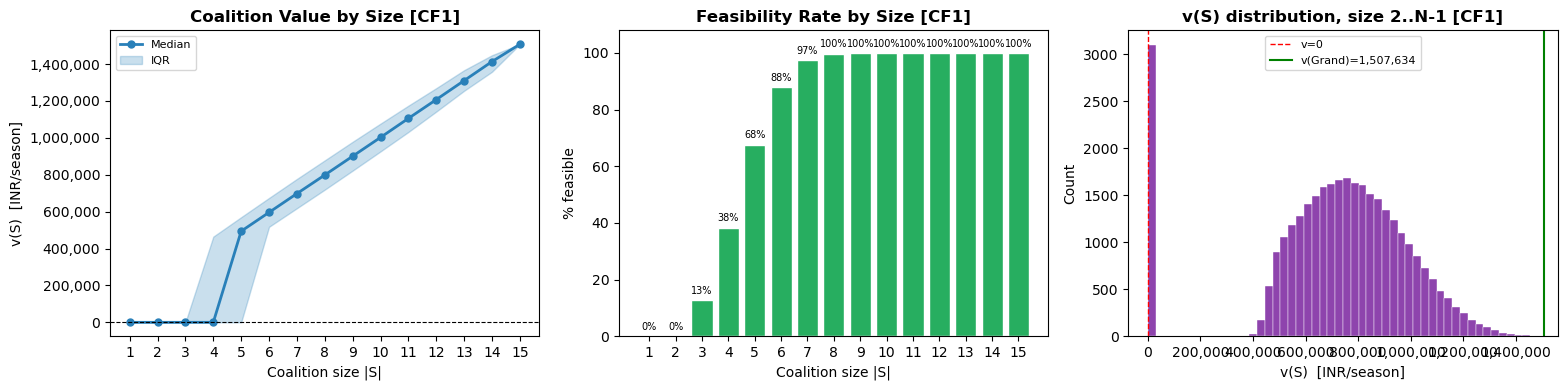

Figure saved.


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Median value by size
ax = axes[0]
sizes   = list(range(1, N+1))
medians = [np.median(size_stats[sz]) for sz in sizes]
q25     = [np.percentile(size_stats[sz], 25) for sz in sizes]
q75     = [np.percentile(size_stats[sz], 75) for sz in sizes]
ax.plot(sizes, medians, "o-", color="#2980b9", linewidth=2, markersize=5, label="Median")
ax.fill_between(sizes, q25, q75, alpha=0.25, color="#2980b9", label="IQR")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Coalition Value by Size [{config.CF_RULE}]", fontweight="bold")
ax.set_xlabel("Coalition size |S|")
ax.set_ylabel("v(S)  [INR/season]")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=8)
ax.set_xticks(sizes)

# Plot 2: Feasibility rate by size
ax = axes[1]
n_total = [len(size_stats[sz]) for sz in sizes]
feas_rate = [100 * n_feasible_by_size[sz] / max(n_total[sz-1], 1) for sz in sizes]
ax.bar(sizes, feas_rate, color="#27ae60", edgecolor="white")
ax.set_title(f"Feasibility Rate by Size [{config.CF_RULE}]", fontweight="bold")
ax.set_xlabel("Coalition size |S|")
ax.set_ylabel("% feasible")
ax.set_ylim(0, 108)
ax.set_xticks(sizes)
for sz, fr in zip(sizes, feas_rate):
    ax.text(sz, fr + 1.5, f"{fr:.0f}%", ha="center", va="bottom", fontsize=7)

# Plot 3: v(S) distribution for size 2..N-1
ax = axes[2]
mid_vals = [v for key, v in characteristic_function.items() if 2 <= len(key) <= N-1]
ax.hist(mid_vals, bins=50, color="#8e44ad", edgecolor="white", linewidth=0.3)
ax.axvline(0,    color="red",   linewidth=1,   linestyle="--", label="v=0")
ax.axvline(v_gc, color="green", linewidth=1.5, linestyle="-",
           label=f"v(Grand)={v_gc:,.0f}")
ax.set_title(f"v(S) distribution, size 2..N-1 [{config.CF_RULE}]", fontweight="bold")
ax.set_xlabel("v(S)  [INR/season]")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    f"{config.PROCESSED_DIR}/nb03_coalition_overview_{config.CF_RULE}.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Figure saved.")

## 11. Save characteristic function

In [15]:
grand_coalition_portfolios: Dict[str, List[int]] = {}
if grand_coalition_result and grand_coalition_result["portfolios"]:
    for i, port in grand_coalition_result["portfolios"].items():
        grand_coalition_portfolios[farmer_lookup[i][0]] = port

all_times = (
    [singleton_results[fid]["solve_time_s"] for fid in farmer_ids]
    + [r["solve_time_s"] for r in raw_results]
)
solve_stats = {
    "cf_rule"           : config.CF_RULE,
    "total_coalitions"  : len(characteristic_function),
    "n_optimal"         : sum(1 for m in coalition_meta.values() if m["status"] == "optimal"),
    "n_infeasible"      : sum(1 for m in coalition_meta.values() if m["status"] != "optimal"),
    "total_solve_time_s": sum(all_times),
    "mean_solve_time_s" : float(np.mean(all_times)),
    "max_solve_time_s"  : float(np.max(all_times)),
}

output_dict = {
    "characteristic_function"   : characteristic_function,
    "grand_coalition_key"       : grand_coalition_key,
    "grand_coalition_value"     : v_gc,
    "grand_coalition_portfolios": grand_coalition_portfolios,
    "farmer_ids"                : farmer_ids,
    "practice_names"            : practice_names,
    "coalition_meta"            : coalition_meta,
    "solve_stats"               : solve_stats,
    "cf_rule"                   : config.CF_RULE,
}

out_path = Path(config.CHARACTERISTIC_FN_PKL)
with open(out_path, "wb") as f:
    pickle.dump(output_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved: {out_path.resolve()}")
print(f"File size: {out_path.stat().st_size / 1024**2:.2f} MB")
print()
for k, v in solve_stats.items():
    print(f"  {k:<25}: {v}")

Saved: /data1/home/rohitsuresh/CGT_Carbon_farming/data/processed/Experiment_CF1_DELTA0/characteristic_function.pkl
File size: 3.57 MB

  cf_rule                  : CF1
  total_coalitions         : 32767
  n_optimal                : 29655
  n_infeasible             : 3112
  total_solve_time_s       : 12940.598306114087
  mean_solve_time_s        : 0.39492777203021595
  max_solve_time_s         : 1.021793097956106


## 12. Reload and verify

In [16]:
with open(config.CHARACTERISTIC_FN_PKL, "rb") as f:
    loaded = pickle.load(f)

assert len(loaded["characteristic_function"]) == 2**N - 1
assert abs(loaded["grand_coalition_value"] - v_gc) < 1.0
assert loaded["cf_rule"] == config.CF_RULE
for key in list(loaded["characteristic_function"].keys())[:200]:
    assert abs(loaded["characteristic_function"][key] - characteristic_function[key]) < 1e-6

print("Pickle reload: PASS ✓")
print()
print("=" * 55)
print("NOTEBOOK 03 COMPLETE")
print("=" * 55)
print(f"  CF_RULE             : {config.CF_RULE}")
print(f"  Coalitions solved   : {len(characteristic_function):,}")
print(f"  v(Grand coalition)  : {v_gc:,.0f} INR")
print(f"  Output              : {config.CHARACTERISTIC_FN_PKL}")
print()
print("Ready for Notebook 04 — Surplus Allocation")

Pickle reload: PASS ✓

NOTEBOOK 03 COMPLETE
  CF_RULE             : CF1
  Coalitions solved   : 32,767
  v(Grand coalition)  : 1,507,634 INR
  Output              : /data1/home/rohitsuresh/CGT_Carbon_farming/data/processed/Experiment_CF1_DELTA0/characteristic_function.pkl

Ready for Notebook 04 — Surplus Allocation
